In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
customers = pd.read_csv(r"C:/Users\DELL/Desktop/Capstone Project/D2C-Capstone/data/customers.csv")

orders = pd.read_csv(r"C:/Users\DELL/Desktop/Capstone Project/D2C-Capstone/data/orders.csv")

tickets = pd.read_csv(r"C:/Users\DELL/Desktop/Capstone Project/D2C-Capstone/data/support_tickets.csv")

web = pd.read_csv(r"C:/Users\DELL/Desktop/Capstone Project/D2C-Capstone/data/web_events_snapshot.csv")

churn = pd.read_csv(r"C:/Users\DELL/Desktop/Capstone Project/D2C-Capstone/data/churn_labels.csv")

intervention = pd.read_csv(r"C:/Users\DELL/Desktop/Capstone Project/D2C-Capstone/data/intervention_history.csv")

In [5]:
customers.head()

,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes
3,CUST00004,2025-04-15,Tier 3,25-34,Google Search,NaN,Fragrance,Normal,No
4,CUST00005,2024-08-21,Tier 3,35-44,Organic,Gold,Hair Care,Combination,Yes


In [6]:
orders.head()

,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
0,ORD000001,CUST00001,2024-08-06,Skin Care,1,540.70,0.43,3,0,4.0
1,ORD000002,CUST00001,2024-10-23,Hair Care,2,467.96,0.64,4,1,1.0
2,ORD000006,CUST00001,2025-01-18,Makeup,1,581.81,0.27,7,0,4.0
3,ORD000005,CUST00001,2025-01-22,Hair Care,1,433.15,0.27,2,0,4.0
4,ORD000004,CUST00001,2025-02-28,Skin Care,1,569.22,0.34,4,0,4.0


In [7]:
orders["order_date"] = pd.to_datetime(
    orders["order_date"]
)

In [8]:
snapshot_date = pd.to_datetime(
    "2025-09-30"
)

snapshot_date

Timestamp('2025-09-30 00:00:00')

In [9]:
orders_filtered = orders[
    orders["order_date"] <= snapshot_date
]

In [10]:
print("Original Orders:", len(orders))

print("Filtered Orders:", len(orders_filtered))

Original Orders: 10009
Filtered Orders: 8137


In [11]:
rfm = orders_filtered.groupby(
    "customer_id"
).agg({
    "order_date": lambda x:
        (snapshot_date - x.max()).days,

    "order_id": "count",

    "gross_amount": "sum"
}).reset_index()

In [12]:
rfm.columns = [
    "customer_id",
    "recency",
    "frequency",
    "monetary"
]

In [13]:
rfm.head()

,customer_id,recency,frequency,monetary
0,CUST00001,107,6,2955.57
1,CUST00002,40,1,581.00
2,CUST00003,171,1,649.98
3,CUST00004,131,1,1604.04
4,CUST00005,38,4,2550.91


In [14]:
rfm.describe()

,recency,frequency,monetary
count,2400.000000,2400.000000,2400.000000
mean,87.375833,3.390417,2549.655729
std,80.137473,2.383350,2129.104340
min,0.000000,1.000000,149.000000
25%,25.000000,1.000000,955.380000
50%,66.000000,3.000000,2012.020000
75%,129.000000,5.000000,3566.080000
max,562.000000,16.000000,27215.920000


In [15]:
rfm.describe()

,recency,frequency,monetary
count,2400.000000,2400.000000,2400.000000
mean,87.375833,3.390417,2549.655729
std,80.137473,2.383350,2129.104340
min,0.000000,1.000000,149.000000
25%,25.000000,1.000000,955.380000
50%,66.000000,3.000000,2012.020000
75%,129.000000,5.000000,3566.080000
max,562.000000,16.000000,27215.920000


In [16]:
rfm["R_score"] = pd.qcut(
    rfm["recency"],
    5,
    labels=[5,4,3,2,1]
)

In [17]:
rfm["F_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

In [18]:
rfm["M_score"] = pd.qcut(
    rfm["monetary"],
    5,
    labels=[1,2,3,4,5]
)

In [19]:
rfm.head()

,customer_id,recency,frequency,monetary,R_score,F_score,M_score
0,CUST00001,107,6,2955.57,2,5,4
1,CUST00002,40,1,581.00,4,1,1
2,CUST00003,171,1,649.98,1,1,1
3,CUST00004,131,1,1604.04,2,1,3
4,CUST00005,38,4,2550.91,4,3,3


In [20]:
rfm[[
    "R_score",
    "F_score",
    "M_score"
]].describe()

,R_score,F_score,M_score
count,2400,2400,2400
unique,5,5,5
top,5,1,1
freq,500,480,480


In [21]:
rfm.head()

,customer_id,recency,frequency,monetary,R_score,F_score,M_score
0,CUST00001,107,6,2955.57,2,5,4
1,CUST00002,40,1,581.00,4,1,1
2,CUST00003,171,1,649.98,1,1,1
3,CUST00004,131,1,1604.04,2,1,3
4,CUST00005,38,4,2550.91,4,3,3


In [22]:
rfm["RFM_score"] = (
    rfm["R_score"].astype(str) +
    rfm["F_score"].astype(str) +
    rfm["M_score"].astype(str)
)

In [23]:
rfm.head()

,customer_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score
0,CUST00001,107,6,2955.57,2,5,4,254
1,CUST00002,40,1,581.00,4,1,1,411
2,CUST00003,171,1,649.98,1,1,1,111
3,CUST00004,131,1,1604.04,2,1,3,213
4,CUST00005,38,4,2550.91,4,3,3,433


In [24]:
def segment_customer(row):

    if row["R_score"] >= 4 and row["F_score"] >= 4 and row["M_score"] >= 4:
        return "Champion"

    elif row["F_score"] >= 4 and row["M_score"] >= 4:
        return "Loyal Customer"

    elif row["R_score"] <= 2 and row["F_score"] >= 3:
        return "At Risk"

    elif row["R_score"] <= 2 and row["F_score"] <= 2:
        return "Dormant"

    else:
        return "Potential Loyalist"

In [25]:
rfm["segment"] = rfm.apply(
    segment_customer,
    axis=1
)

In [26]:
rfm[
    [
        "customer_id",
        "RFM_score",
        "segment"
    ]
].head(10)

,customer_id,RFM_score,segment
0,CUST00001,254,Loyal Customer
1,CUST00002,411,Potential Loyalist
2,CUST00003,111,Dormant
3,CUST00004,213,Dormant
4,CUST00005,433,Potential Loyalist
5,CUST00006,344,Loyal Customer
6,CUST00007,511,Potential Loyalist
7,CUST00008,334,Potential Loyalist
8,CUST00009,411,Potential Loyalist
9,CUST00010,511,Potential Loyalist


In [27]:
rfm["segment"].value_counts()

segment
Potential Loyalist    922
Loyal Customer        480
Dormant               381
Champion              344
At Risk               273
Name: count, dtype: int64

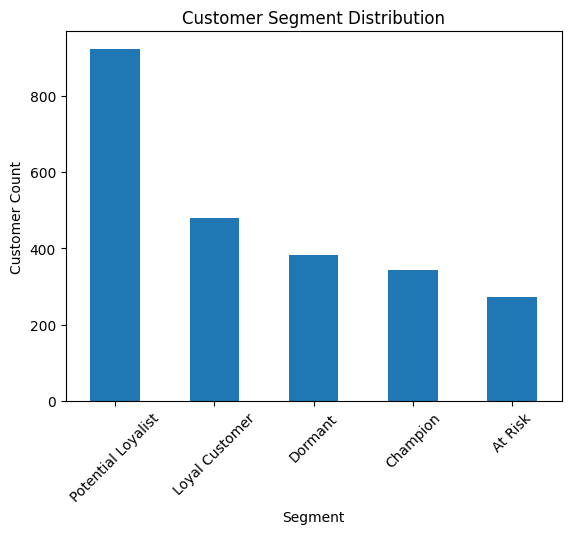

In [28]:
rfm["segment"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Segment Distribution")

plt.xlabel("Segment")

plt.ylabel("Customer Count")

plt.xticks(rotation=45)

plt.show()

In [29]:
rfm.to_csv(
    "segments.csv",
    index=False
)

In [30]:
ticket_summary = tickets.groupby(
    "customer_id"
).agg({
    "ticket_id": "count"
}).reset_index()

In [31]:
ticket_summary.columns = [
    "customer_id",
    "ticket_count"
]

In [32]:
rfm = rfm.merge(
    ticket_summary,
    on="customer_id",
    how="left"
)

In [33]:
rfm["ticket_count"] = (
    rfm["ticket_count"]
    .fillna(0)
)

In [34]:
rfm.head()

,customer_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,segment,ticket_count
0,CUST00001,107,6,2955.57,2,5,4,254,Loyal Customer,2.0
1,CUST00002,40,1,581.00,4,1,1,411,Potential Loyalist,1.0
2,CUST00003,171,1,649.98,1,1,1,111,Dormant,0.0
3,CUST00004,131,1,1604.04,2,1,3,213,Dormant,0.0
4,CUST00005,38,4,2550.91,4,3,3,433,Potential Loyalist,1.0


In [35]:
web_summary = web[
    [
        "customer_id",
        "sessions_30d"
    ]
]

In [38]:
web.columns

Index(['customer_id', 'snapshot_date', 'sessions_30d', 'product_views_30d',
       'cart_adds_30d', 'wishlist_adds_30d', 'abandoned_carts_30d',
       'email_opens_30d', 'campaign_clicks_30d', 'last_visit_days_ago'],
      dtype='str')

In [39]:
web.head()

,customer_id,snapshot_date,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago
0,CUST00001,2025-09-30,1,4,0,0,0,2,0,20
1,CUST00002,2025-09-30,8,31,4,2,3,0,0,0
2,CUST00003,2025-09-30,1,3,0,0,0,0,0,26
3,CUST00004,2025-09-30,1,6,0,0,0,0,0,14
4,CUST00005,2025-09-30,18,95,4,1,1,3,1,9


In [40]:
web.columns

Index(['customer_id', 'snapshot_date', 'sessions_30d', 'product_views_30d',
       'cart_adds_30d', 'wishlist_adds_30d', 'abandoned_carts_30d',
       'email_opens_30d', 'campaign_clicks_30d', 'last_visit_days_ago'],
      dtype='str')

In [41]:
rfm = rfm.merge(
    web_summary,
    on="customer_id",
    how="left"
)

In [42]:
rfm["sessions_30d"] = (
    rfm["sessions_30d"]
    .fillna(0)
)

In [43]:
rfm.head()

,customer_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,segment,ticket_count,sessions_30d
0,CUST00001,107,6,2955.57,2,5,4,254,Loyal Customer,2.0,1
1,CUST00002,40,1,581.00,4,1,1,411,Potential Loyalist,1.0,8
2,CUST00003,171,1,649.98,1,1,1,111,Dormant,0.0,1
3,CUST00004,131,1,1604.04,2,1,3,213,Dormant,0.0,1
4,CUST00005,38,4,2550.91,4,3,3,433,Potential Loyalist,1.0,18


In [44]:
web_summary

,customer_id,sessions_30d
0,CUST00001,1
1,CUST00002,8
2,CUST00003,1
3,CUST00004,1
4,CUST00005,18
...,...,...
2395,CUST02396,1
2396,CUST02397,12
2397,CUST02398,4
2398,CUST02399,1


In [45]:
rfm.head()

,customer_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,segment,ticket_count,sessions_30d
0,CUST00001,107,6,2955.57,2,5,4,254,Loyal Customer,2.0,1
1,CUST00002,40,1,581.00,4,1,1,411,Potential Loyalist,1.0,8
2,CUST00003,171,1,649.98,1,1,1,111,Dormant,0.0,1
3,CUST00004,131,1,1604.04,2,1,3,213,Dormant,0.0,1
4,CUST00005,38,4,2550.91,4,3,3,433,Potential Loyalist,1.0,18


In [46]:
high_value_unhappy = rfm[
    (rfm["M_score"] >= 4) &
    (rfm["ticket_count"] >= 2)
]

high_value_unhappy.head(10)

,customer_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,segment,ticket_count,sessions_30d
0,CUST00001,107,6,2955.57,2,5,4,254,Loyal Customer,2.0,1
5,CUST00006,51,5,3770.16,3,4,4,344,Loyal Customer,2.0,2
13,CUST00014,51,11,8130.16,3,5,5,355,Loyal Customer,2.0,11
24,CUST00025,165,7,4868.86,1,5,5,155,Loyal Customer,3.0,11
29,CUST00030,5,6,3435.59,5,5,4,554,Champion,2.0,11
33,CUST00034,50,6,3353.01,3,5,4,354,Loyal Customer,3.0,7
41,CUST00042,87,9,7523.74,2,5,5,255,Loyal Customer,6.0,3
50,CUST00051,210,4,4444.30,1,3,5,135,At Risk,2.0,6
52,CUST00053,25,4,4192.59,4,3,5,435,Potential Loyalist,2.0,9
74,CUST00075,3,9,6791.61,5,5,5,555,Champion,4.0,10


In [47]:
high_value_inactive = rfm[
    (rfm["M_score"] >= 4) &
    (rfm["sessions_30d"] <= 2)
]

high_value_inactive.head(10)

,customer_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,segment,ticket_count,sessions_30d
0,CUST00001,107,6,2955.57,2,5,4,254,Loyal Customer,2.0,1
5,CUST00006,51,5,3770.16,3,4,4,344,Loyal Customer,2.0,2
7,CUST00008,47,4,2747.33,3,3,4,334,Potential Loyalist,1.0,2
19,CUST00020,368,3,4487.95,1,3,5,135,At Risk,1.0,0
28,CUST00029,18,8,5252.90,5,5,5,555,Champion,0.0,1
96,CUST00097,1,7,4703.46,5,5,5,555,Champion,2.0,0
100,CUST00101,108,5,3514.87,2,4,4,244,Loyal Customer,2.0,2
106,CUST00107,12,3,3548.15,5,3,4,534,Potential Loyalist,0.0,2
108,CUST00109,92,5,3837.05,2,4,4,244,Loyal Customer,0.0,1
122,CUST00123,102,6,2989.07,2,5,4,254,Loyal Customer,3.0,2


In [48]:
segment_summary = rfm.groupby("segment").agg({
    "customer_id": "count",
    "monetary": "mean",
    "frequency": "mean",
    "ticket_count": "mean",
    "sessions_30d": "mean"
}).round(2)

segment_summary

,customer_id,monetary,frequency,ticket_count,sessions_30d
segment,,,,,
At Risk,273,2110.13,3.12,0.75,3.47
Champion,344,4920.77,6.38,1.46,7.28
Dormant,381,986.73,1.31,0.33,3.71
Loyal Customer,480,4604.26,5.84,1.36,4.81
Potential Loyalist,922,1371.34,1.94,0.47,6.44


In [49]:
high_value_unhappy.head(10)

,customer_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,segment,ticket_count,sessions_30d
0,CUST00001,107,6,2955.57,2,5,4,254,Loyal Customer,2.0,1
5,CUST00006,51,5,3770.16,3,4,4,344,Loyal Customer,2.0,2
13,CUST00014,51,11,8130.16,3,5,5,355,Loyal Customer,2.0,11
24,CUST00025,165,7,4868.86,1,5,5,155,Loyal Customer,3.0,11
29,CUST00030,5,6,3435.59,5,5,4,554,Champion,2.0,11
33,CUST00034,50,6,3353.01,3,5,4,354,Loyal Customer,3.0,7
41,CUST00042,87,9,7523.74,2,5,5,255,Loyal Customer,6.0,3
50,CUST00051,210,4,4444.30,1,3,5,135,At Risk,2.0,6
52,CUST00053,25,4,4192.59,4,3,5,435,Potential Loyalist,2.0,9
74,CUST00075,3,9,6791.61,5,5,5,555,Champion,4.0,10


In [50]:
high_value_inactive.head(10)

,customer_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,segment,ticket_count,sessions_30d
0,CUST00001,107,6,2955.57,2,5,4,254,Loyal Customer,2.0,1
5,CUST00006,51,5,3770.16,3,4,4,344,Loyal Customer,2.0,2
7,CUST00008,47,4,2747.33,3,3,4,334,Potential Loyalist,1.0,2
19,CUST00020,368,3,4487.95,1,3,5,135,At Risk,1.0,0
28,CUST00029,18,8,5252.90,5,5,5,555,Champion,0.0,1
96,CUST00097,1,7,4703.46,5,5,5,555,Champion,2.0,0
100,CUST00101,108,5,3514.87,2,4,4,244,Loyal Customer,2.0,2
106,CUST00107,12,3,3548.15,5,3,4,534,Potential Loyalist,0.0,2
108,CUST00109,92,5,3837.05,2,4,4,244,Loyal Customer,0.0,1
122,CUST00123,102,6,2989.07,2,5,4,254,Loyal Customer,3.0,2


In [51]:
segment_summary

,customer_id,monetary,frequency,ticket_count,sessions_30d
segment,,,,,
At Risk,273,2110.13,3.12,0.75,3.47
Champion,344,4920.77,6.38,1.46,7.28
Dormant,381,986.73,1.31,0.33,3.71
Loyal Customer,480,4604.26,5.84,1.36,4.81
Potential Loyalist,922,1371.34,1.94,0.47,6.44


In [52]:
manual_review = rfm[
    [
        "customer_id",
        "segment",
        "monetary",
        "ticket_count",
        "sessions_30d"
    ]
].head(10)

manual_review

,customer_id,segment,monetary,ticket_count,sessions_30d
0,CUST00001,Loyal Customer,2955.57,2.0,1
1,CUST00002,Potential Loyalist,581.00,1.0,8
2,CUST00003,Dormant,649.98,0.0,1
3,CUST00004,Dormant,1604.04,0.0,1
4,CUST00005,Potential Loyalist,2550.91,1.0,18
5,CUST00006,Loyal Customer,3770.16,2.0,2
6,CUST00007,Potential Loyalist,719.33,0.0,11
7,CUST00008,Potential Loyalist,2747.33,1.0,2
8,CUST00009,Potential Loyalist,376.85,0.0,11
9,CUST00010,Potential Loyalist,636.80,0.0,13


In [53]:
manual_review.to_csv(
    "manual_review_cases.csv",
    index=False
)

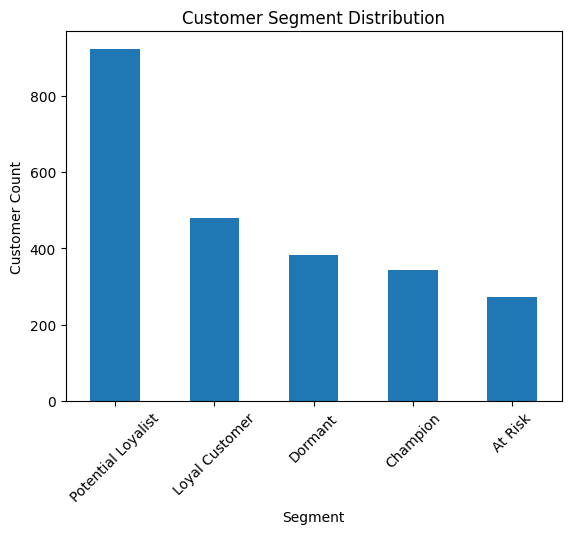

In [54]:
rfm["segment"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Segment Distribution")

plt.xlabel("Segment")

plt.ylabel("Customer Count")

plt.xticks(rotation=45)

plt.show()

In [55]:
rfm["segment"].value_counts()

segment
Potential Loyalist    922
Loyal Customer        480
Dormant               381
Champion              344
At Risk               273
Name: count, dtype: int64